In [1]:
import torch
import torch.nn as nn
import math
import pandas as pd
import numpy as np
import copy
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset, DataLoader
from tqdm import tqdm
from sklearn.metrics import precision_recall_fscore_support, classification_report, confusion_matrix, cohen_kappa_score
import seaborn as sns
import os
import matplotlib.pyplot as plt

In [2]:

EXTRA_COLS = ['clim_precip', 'clim_temp', 'soil_texture', 'topo_elevation', 'topo_slope']
IN_CHANNELS = 14 + len(EXTRA_COLS)  
MODEL_NAME  = 'model_arkansas_cnn_gru'

In [ ]:
class CNNFeatureExtractor_V2(nn.Module):
    def __init__(self, in_channels=19):
        super(CNNFeatureExtractor_V2, self).__init__()
        
        self.conv1 = nn.Conv1d(in_channels, 128, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm1d(128)
        self.conv2 = nn.Conv1d(128, 128, kernel_size=3, padding=2, dilation=2) 
        self.bn2 = nn.BatchNorm1d(128)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
       
        x = x.transpose(1, 2)
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.dropout(x)
        x = self.relu(self.bn2(self.conv2(x)))
      
        return x.transpose(1, 2)

class BiGRUProcessor_V2(nn.Module):
    def __init__(self, input_dim=128, hidden_dim=128):
        super(BiGRUProcessor_V2, self).__init__()
       
        self.gru = nn.GRU(input_dim, hidden_dim, batch_first=True, bidirectional=True) # *2 dim car bi
       
        
    def forward(self, x):
        out, _ = self.gru(x)
        return out



class TemporalAttention(nn.Module):
    def __init__(self, hidden_dim=256):
        super(TemporalAttention, self).__init__()
      
        self.attn = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        
        
        
        energy = self.attn(x) 
        
        weights = torch.softmax(energy, dim=1) 
        

        context = torch.sum(weights * x, dim=1) 
        
        return context, weights



class HybridCropNet_V2(nn.Module):
    def __init__(self, num_classes=6, in_channels=19):
        super(HybridCropNet_V2, self).__init__()
        self.feature_extractor = CNNFeatureExtractor_V2(in_channels=in_channels)
        self.sequence_processor = BiGRUProcessor_V2(input_dim=128, hidden_dim=128)
        self.attention = TemporalAttention(hidden_dim=256) 
        
        self.classifier = nn.Sequential(
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.feature_extractor(x)  
        x = self.sequence_processor(x)
        context, weights = self.attention(x)
        logits = self.classifier(context)
        return logits, weights

In [6]:
df_ark = pd.read_csv('../data/arkansas_preprocessed_v2.csv')
df_ark.head()

,d0_B2,d0_B3,d0_B4,d0_B5,d0_B6,d0_B7,d0_B8,d0_B8A,d0_B11,d0_B12,...,d35_B8A,d35_B11,d35_B12,clim_precip,clim_temp,soil_texture,topo_elevation,topo_slope,cropland,target_class
0,0.0505,0.0758,0.10135,0.12890,0.1361,0.14435,0.16065,0.15805,0.11945,0.07645,...,0.19435,0.1425,0.09335,-1.852316,-2.559609,0.545543,0.527846,-0.696317,3,2
1,0.0645,0.0857,0.11530,0.13840,0.1542,0.16320,0.18710,0.18750,0.25540,0.19040,...,0.24080,0.2744,0.18450,-0.435476,-0.189180,0.545543,0.067849,-0.696317,2,1
2,0.0867,0.1072,0.14110,0.15910,0.1697,0.18090,0.20630,0.20340,0.22120,0.15450,...,0.20600,0.2376,0.17190,-0.874820,-0.424767,0.545543,0.251848,-1.295287,1,0
3,0.0631,0.0884,0.11200,0.14830,0.1979,0.21770,0.24190,0.23800,0.24200,0.17210,...,0.24190,0.3148,0.24250,0.735092,1.232434,0.545543,-1.036141,0.500368,2,1
4,0.0590,0.0772,0.09770,0.11405,0.1153,0.12705,0.13900,0.13425,0.13860,0.08885,...,0.09675,0.1053,0.06840,-0.436471,-0.184275,-1.790829,0.113849,-1.295287,1,0


In [7]:
mapping_ark = {1: 0, 2: 1, 3: 2, 5: 3}
def map_classes_ark(val):
    return mapping_ark.get(val, 4)

df_ark['target_class'] = df_ark['cropland'].apply(map_classes_ark)

targets_ark = {0: 4677, 1: 762, 2: 2423, 3: 1522, 4: 616}
sampled_dfs = []
for class_id, count in targets_ark.items():
    sub_df = df_ark[df_ark['target_class'] == class_id]
    sampled_dfs.append(sub_df.sample(n=min(len(sub_df), count), random_state=42))

df_ark_final = pd.concat(sampled_dfs).sample(frac=1, random_state=42)
print(df_ark_final['target_class'].value_counts())

target_class
0    4677
2    2423
3    1522
1     762
4     616
Name: count, dtype: int64


In [8]:
print(df_ark['target_class'].value_counts())
print(f"Total : {len(df_ark)}")

target_class
0    4677
2    2423
3    1522
1     762
4     616
Name: count, dtype: int64
Total : 10000


In [ ]:
def prepare_mixed_hybrid_data(df, extra_cols):
    """
    Prépare les données en mode 'Mixte' (14 spectrales + 5 environnementales).
    Total features par date : 19
    Format de sortie : [Batch, 36, 19]
    """
    BANDS = ['B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B11', 'B12']
    

    for i in range(36):
        b3, b4, b5, b8 = df[f'd{i}_B3'], df[f'd{i}_B4'], df[f'd{i}_B5'], df[f'd{i}_B8']
        df[f'd{i}_NDVI']  = (b8 - b4) / (b8 + b4 + 1e-8)
        df[f'd{i}_NDRE']  = (b8 - b5) / (b8 + b5 + 1e-8)
        df[f'd{i}_LCI']   = (b8 - b5) / (b8 + b4 + 1e-8)
        df[f'd{i}_GNDVI'] = (b8 - b3) / (b8 + b3 + 1e-8)


    PURE_FEATURES = BANDS + ['NDVI', 'NDRE', 'LCI', 'GNDVI']
    ordered_cols = [f'd{i}_{feat}' for i in range(36) for feat in PURE_FEATURES]
    x_spectral = torch.tensor(df[ordered_cols].values, dtype=torch.float32).view(-1, 36, 14)
    

    if extra_cols and len(extra_cols) > 0:
      
        x_extra = torch.tensor(df[extra_cols].values, dtype=torch.float32)
       
        x_extra_expanded = x_extra.unsqueeze(1).expand(-1, 36, -1)
        
        x_final = torch.cat([x_spectral, x_extra_expanded], dim=-1)
    else:
        x_final = x_spectral
    
    y = torch.tensor(df['target_class'].values, dtype=torch.long)
    return x_final, y


EXTRA_COLS = ['clim_precip', 'clim_temp', 'soil_texture', 'topo_elevation', 'topo_slope']
IN_CHANNELS = 14 + len(EXTRA_COLS) 

x_ark, y_ark = prepare_mixed_hybrid_data(df_ark_final, EXTRA_COLS)

print(f'Nouveau Shape X: {x_ark.shape}') 

Nouveau Shape X: torch.Size([10000, 36, 19])


C:\Users\lhadi\AppData\Local\Temp\ipykernel_16468\590579815.py:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'd{i}_NDVI']  = (b8 - b4) / (b8 + b4 + 1e-8)
C:\Users\lhadi\AppData\Local\Temp\ipykernel_16468\590579815.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'd{i}_NDRE']  = (b8 - b5) / (b8 + b5 + 1e-8)
C:\Users\lhadi\AppData\Local\Temp\ipykernel_16468\590579815.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performanc

In [ ]:

x_train, x_temp, y_train, y_temp = train_test_split(
    x_ark, y_ark, test_size=0.18, stratify=y_ark, random_state=96
)
x_val, x_test, y_val, y_test = train_test_split(
    x_temp, y_temp, test_size=0.8, stratify=y_temp, random_state=96
)


train_loader = DataLoader(TensorDataset(x_train, y_train), batch_size=256, shuffle=True)
val_loader   = DataLoader(TensorDataset(x_val, y_val),   batch_size=256)
test_loader  = DataLoader(TensorDataset(x_test, y_test),  batch_size=256)

In [ ]:
import copy
from sklearn.metrics import precision_recall_fscore_support
import numpy as np
import torch
from tqdm import tqdm
from torch.optim.lr_scheduler import ReduceLROnPlateau
import torch.nn.functional as F


class FocalLoss(torch.nn.Module):
    def __init__(self, alpha=1, gamma=1.5, weight=None): 
        super(FocalLoss, self).__init__()
        self.gamma = gamma
        self.alpha = alpha
        self.weight = weight

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none', weight=self.weight, label_smoothing=0.1)
        pt = torch.exp(-ce_loss)
        focal_loss = self.alpha * (1 - pt)**self.gamma * ce_loss
        return focal_loss.mean()

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
epochs = 50 
best_f1 = 0.0
print(f'Device utilisé : {device}')

model = HybridCropNet_V2(num_classes=6, in_channels=IN_CHANNELS).to(device)


optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.01)


weights = torch.tensor([1.1, 1.0, 1.1, 1.8, 1.8, 0.8]).to(device)
criterion = FocalLoss(weight=weights)


scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5)

best_model_state = copy.deepcopy(model.state_dict())

for epoch in range(epochs):
    model.train()
    train_loss = 0
    pbar = tqdm(train_loader, desc=f'Époque {epoch+1}/{epochs}', unit='batch')
    
    for b_x, b_y in pbar:
        b_x, b_y = b_x.to(device), b_y.to(device)
        
        optimizer.zero_grad()
        outputs, _ = model(b_x) 
        loss = criterion(outputs, b_y)
        loss.backward()
     
       

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        train_loss += loss.item()
        pbar.set_postfix(loss=f'{loss.item():.4f}', lr=f'{optimizer.param_groups[0]["lr"]:.6f}')

    model.eval()
    val_preds, val_targets = [], []
    val_loss = 0
    with torch.no_grad():
        for b_x, b_y in val_loader:
            b_x, b_y = b_x.to(device), b_y.to(device)
            outputs, _ = model(b_x)
            val_loss += criterion(outputs, b_y).item()
            _, predicted = torch.max(outputs, 1)
            val_preds.extend(predicted.cpu().numpy())
            val_targets.extend(b_y.cpu().numpy())


    precision, recall, f1, _ = precision_recall_fscore_support(
        val_targets, val_preds, average='macro', zero_division=0
    )
    val_acc = 100 * np.sum(np.array(val_preds) == np.array(val_targets)) / len(val_targets)
    
    
    scheduler.step(f1)
    
    print(f'\n[Validation] Acc: {val_acc:.2f}% | F1-Score: {f1:.4f}')

    if f1 > best_f1:
        best_f1 = f1
        best_model_state = copy.deepcopy(model.state_dict())
        print(f'Nouveau record F1: {best_f1:.4f}')


model.load_state_dict(best_model_state)
print(f'\nEntraînement fini. Meilleur F1 atteint: {best_f1:.4f}')

Device utilisé : cuda


Époque 1/50:   0%|          | 0/33 [00:00<?, ?batch/s]

Époque 1/50: 100%|██████████| 33/33 [00:00<00:00, 75.36batch/s, loss=1.3423, lr=0.001000]



[Validation] Acc: 56.94% | F1-Score: 0.4721
Nouveau record F1: 0.4721


Époque 2/50: 100%|██████████| 33/33 [00:00<00:00, 81.07batch/s, loss=0.7730, lr=0.001000]


...


[Validation] Acc: 93.61% | F1-Score: 0.9323


Époque 49/50: 100%|██████████| 33/33 [00:00<00:00, 100.29batch/s, loss=0.4605, lr=0.000063]



[Validation] Acc: 93.61% | F1-Score: 0.9307


Époque 50/50: 100%|██████████| 33/33 [00:00<00:00, 104.40batch/s, loss=0.2036, lr=0.000063]



[Validation] Acc: 93.61% | F1-Score: 0.9291

Entraînement fini. Meilleur F1 atteint: 0.9407


In [14]:
torch.save(model.state_dict(), f'models/model_arkansas_CNN_GRU.pth')
print('Modèle sauvegardé : model_arkansas_CNN_GRU.pth')

Modèle sauvegardé : model_arkansas_CNN_GRU.pth


=== Test Set - HybridCropNet ===
OA    : 0.9319
Kappa : 0.9020
              precision    recall  f1-score   support

    Soybeans       0.96      0.94      0.95       673
      Cotton       0.97      0.92      0.94       110
        Rice       0.96      0.95      0.96       349
        Corn       0.82      0.88      0.85       219
      Others       0.85      0.96      0.90        89

    accuracy                           0.93      1440
   macro avg       0.91      0.93      0.92      1440
weighted avg       0.93      0.93      0.93      1440



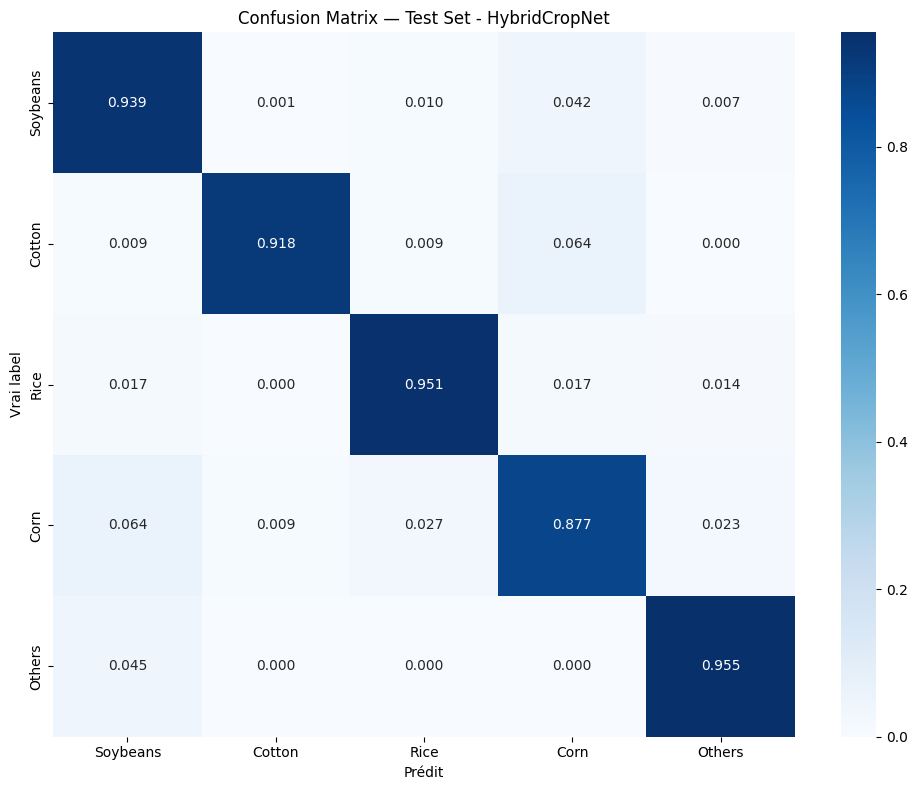

In [ ]:
def evaluate_on_test(model, test_loader, class_names, title):
    model.eval()
    all_preds, all_labels = [], []
    
    with torch.no_grad():
         
        for b_x, b_y in test_loader:
            b_x, b_y = b_x.to(device), b_y.to(device)
            
            
            outputs, _ = model(b_x) 
            
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(b_y.cpu().numpy())
            
    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)
    
    
    oa    = (all_preds == all_labels).mean()
    kappa = cohen_kappa_score(all_labels, all_preds)
    
    print(f'=== {title} ===')
    print(f'OA    : {oa:.4f}')
    print(f'Kappa : {kappa:.4f}')
    
     
    print(classification_report(all_labels, all_preds, target_names=class_names))
    
     
    cm = confusion_matrix(all_labels, all_preds, normalize='true')
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='.3f', xticklabels=class_names,
                yticklabels=class_names, cmap='Blues')
    plt.title(f'Confusion Matrix — {title}')
    plt.ylabel('Vrai label')
    plt.xlabel('Prédit')
    plt.tight_layout()
    
     
    os.makedirs('./figs', exist_ok=True)
    plt.savefig(f'./figs/CNNGRU_confusion_matrix.png', dpi=150)
    plt.show()


class_names = ['Soybeans', 'Cotton', 'Rice', 'Corn', 'Others']
evaluate_on_test(model, test_loader, class_names, title='Test Set - HybridCropNet')